# Single-field dynamic neural field simulation

This notebook demonstrates a basic 1D dynamic neural field with two competing Gaussian inputs. The field implements the Amari equation with lateral inhibition (Mexican hat kernel), producing self-sustaining peaks that persist after input removal.

We then extract target activations at the input positions and track the peak of the field over time.

In [1]:
from pyphonplan import DynamicField, Targets
from pyphonplan.viz import plot_field_heatmap, plot_field_surface, plot_target_activations

## Create the field

Set up a field spanning -10 to 10 with a sigmoidal threshold and a Mexican hat interaction kernel (local excitation, lateral inhibition, global inhibition).

In [2]:
field = DynamicField(x_min=-10, x_max=10, step_size=0.1)
field.set_sigmoid(beta=1.5, threshold=0.0)
field.set_kernel(c_exc=1, c_inh=1, c_global=0.05, sigma_exc=1.0, sigma_inh=5.0, expand=3.0)

### Sigmoid and kernel

The sigmoid gates which parts of the field contribute to self-excitation. The kernel determines the spatial pattern of lateral interactions.

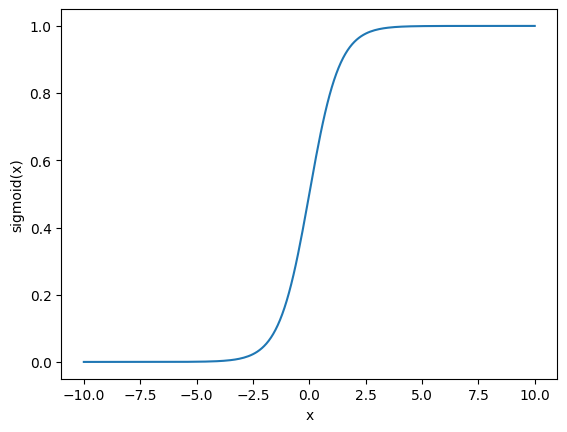

In [3]:
field.plot_sigmoid();

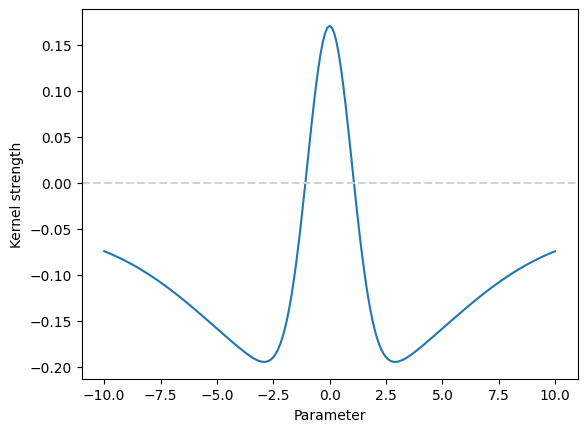

In [4]:
field.plot_kernel();

## Add inputs

Two Gaussian inputs at positions -5 and +5, with staggered timing. `input1` is active from t=50 to 150, `input2` from t=100 to 200.

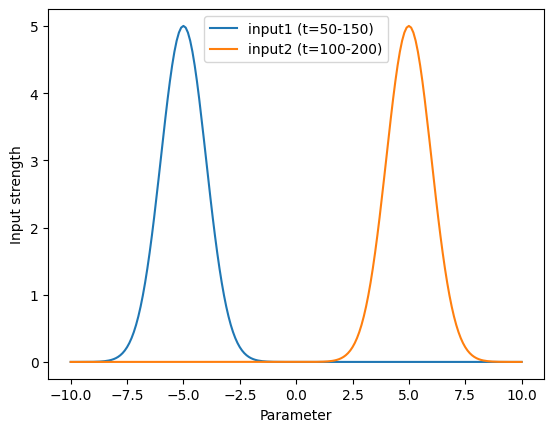

In [5]:
field.add_input("input1", amplitude=5, position=-5, width=1.0, start=50, end=150)
field.add_input("input2", amplitude=5, position=5, width=1.0, start=100, end=200)
field.plot_inputs();

## Solve the field

Integrate the Amari equation using Euler-Maruyama with a small amount of noise.

In [6]:
field.solve(t_start=0, t_end=250, dt=1, tau=25.0, h=-2.0, noise=0.01)

## Visualise field activation

The heatmap shows activation over time (x-axis) and space (y-axis). The white dashed line tracks the peak position.

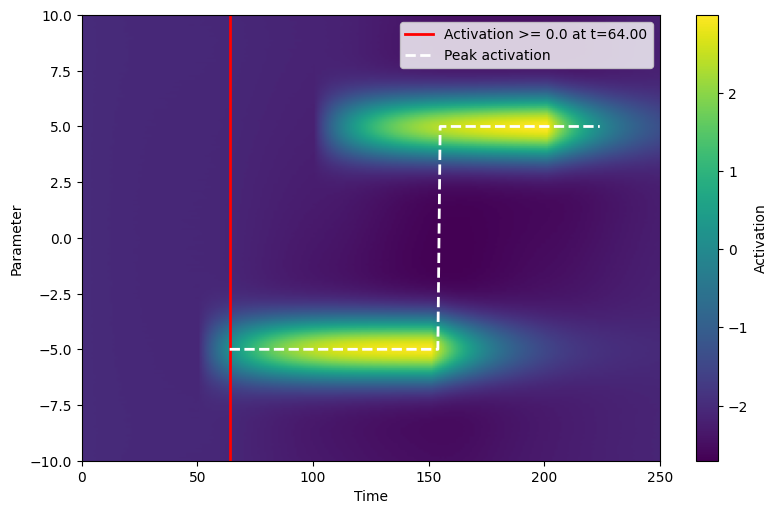

In [7]:
plot_field_heatmap(field.time, field.x, field.activation);

We can also visualise as a 3D surface, where the grey plane shows the user-defined activation threshold.

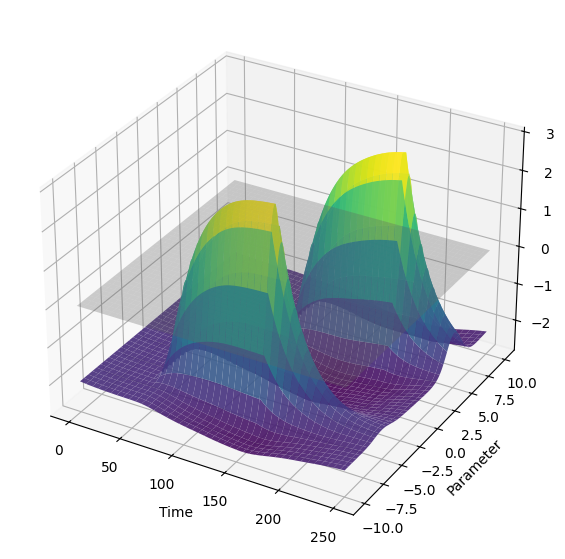

In [8]:
plot_field_surface(field.time, field.x, field.activation, threshold=0.0);

## Extract targets

Extract activation time series at the two input positions and compute onset/offset timing.

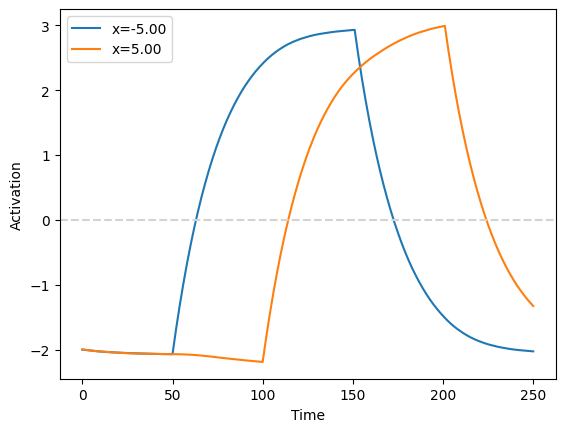

In [9]:
targets = Targets(field, positions=[-5.0, 5.0])
plot_target_activations(field.time, targets.traces);

### Peak activation tracking

Track the position and activation of the field's peak over time. This is the trace that `solve_from_trace()` uses to drive the task dynamic solver.

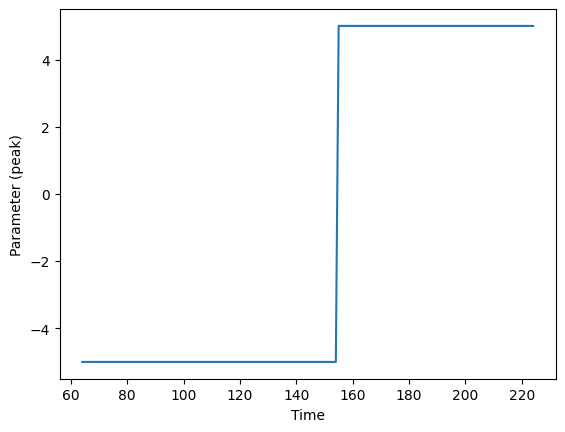

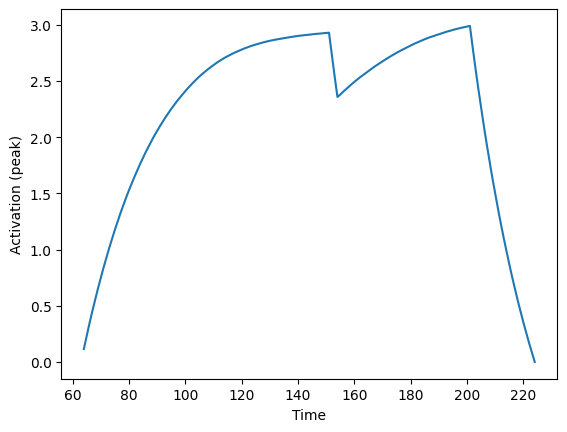

In [10]:
targets.peak_activation(plot=True);

## Animate field activation

Save a frame-by-frame animation of the 1D activation profile showing how peaks emerge and compete over time.

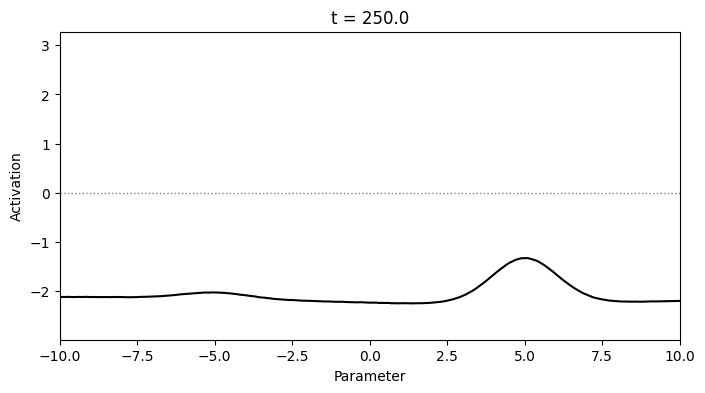

In [12]:
from pyphonplan.viz import animate_field
animate_field(field.time, field.x, field.activation, save_path="single_field.mp4", show=False);